# 02: Data Preprocessing & Cleaning 🧹

In this notebook, we will transform the raw, messy data into a clean, structured format ready for machine learning.

### 🎯 Goals
1.  **Cleaning:** Remove duplicates and "impossible" medical data (e.g., negative blood pressure).
2.  **Outlier Handling:** Remove extreme outliers in Height and Weight using the IQR method.
3.  **Feature Engineering:** Create the `BMI` feature.
4.  **Encoding:** Convert categorical variables into a machine-readable format.
5.  **Scaling:** Normalize numerical features so our Logistic Regression model converges faster.
6.  **Splitting:** Save separate Training and Test sets.

### 🏗️ Components Used
* `pandas`, `numpy`: Data manipulation.
* `seaborn`, `matplotlib`: For "Before & After" visualizations.
* `scikit-learn`: For splitting and scaling.

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib  # For saving the scaler
import os

# Configuration
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Create directories if they don't exist
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../flask_app", exist_ok=True)  # To store the scaler model later

print("Setup Complete.")

Setup Complete.


## 1. Load Data
We read the raw data again

In [2]:
df = pd.read_csv("../data/raw/cardio_train.csv", sep=";")

# Drop 'id' immediately as decided in Step 1
if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

# Convert age to years for readability (and model usage)
df["age"] = (df["age"] / 365.25).round().astype(int)
df.rename(columns={"age": "age_years"}, inplace=True)

print(f"Initial Shape: {df.shape}")
display(df.head())

Initial Shape: (70000, 12)


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,48,1,156,56.0,100,60,1,1,0,0,0,0


## 2. Removing Duplicates
We identified duplicates in the exploration phase. Let's verify and remove them.

In [3]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New Shape: {df.shape}")
else:
    print("No duplicates to remove.")

Duplicates found: 3821
Duplicates removed. New Shape: (66179, 12)


## 3. Cleaning "Impossible" Blood Pressure (BP)
**Justification:**
In Notebook 1, we saw:
* Systolic BP (`ap_hi`) lower than Diastolic (`ap_lo`).
* Negative BP values.
* Extreme values like 16000.

**Visualization (Before Cleaning):**

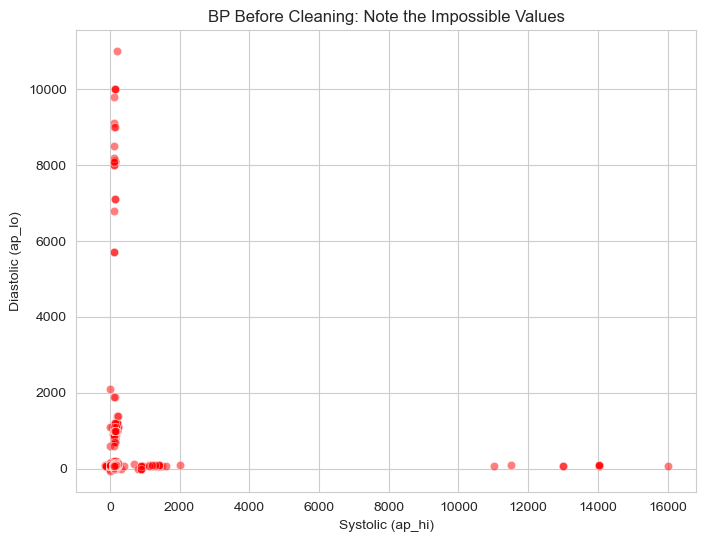

In [4]:
# Scatterplot focusing on the errors
plt.figure(figsize=(8, 6))
sns.scatterplot(x="ap_hi", y="ap_lo", data=df, alpha=0.5, color="red")
plt.title("BP Before Cleaning: Note the Impossible Values")
plt.xlabel("Systolic (ap_hi)")
plt.ylabel("Diastolic (ap_lo)")
plt.show()

**Action:**
We will filter the data to keep only medically reasonable values.
* `ap_hi` > `ap_lo` (Systolic must be higher)
* `ap_hi` between 50 and 250 (Extreme range buffer)
* `ap_lo` between 30 and 150

In [5]:
# Define rules for cleaning
print(f"Rows before BP cleaning: {len(df)}")

# 1. Systolic must be greater than Diastolic
df = df[df["ap_hi"] > df["ap_lo"]]

# 2. Reasonable Medical Ranges
# Systolic: 50 to 250
# Diastolic: 30 to 150
df = df[(df["ap_hi"] >= 50) & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 30) & (df["ap_lo"] <= 150)]

print(f"Rows after BP cleaning: {len(df)}")

Rows before BP cleaning: 66179
Rows after BP cleaning: 64853


**Validation (After Cleaning):**
Let's look at the plot again. It should look like a clean cluster now.

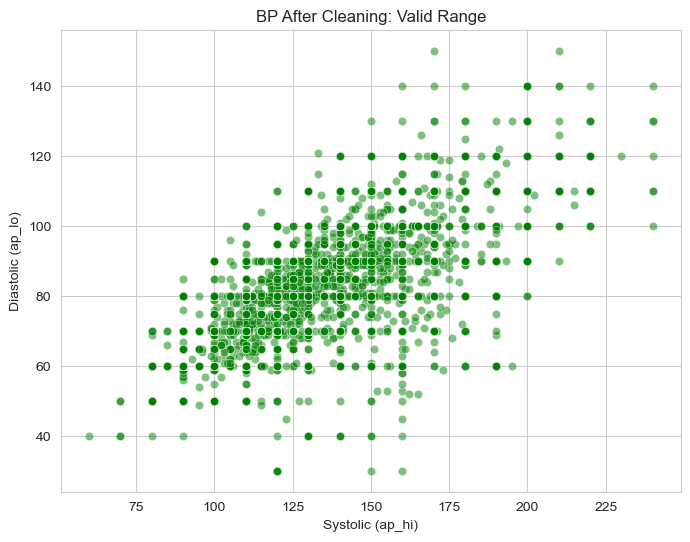

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="ap_hi", y="ap_lo", data=df, alpha=0.5, color="green")
plt.title("BP After Cleaning: Valid Range")
plt.xlabel("Systolic (ap_hi)")
plt.ylabel("Diastolic (ap_lo)")
plt.show()

## 4. Handling Outliers (Height & Weight)
**Justification:**
We saw extremely short people (e.g., 50cm) and extremely light weights. These are likely data entry errors.

**Visualization (Before):**

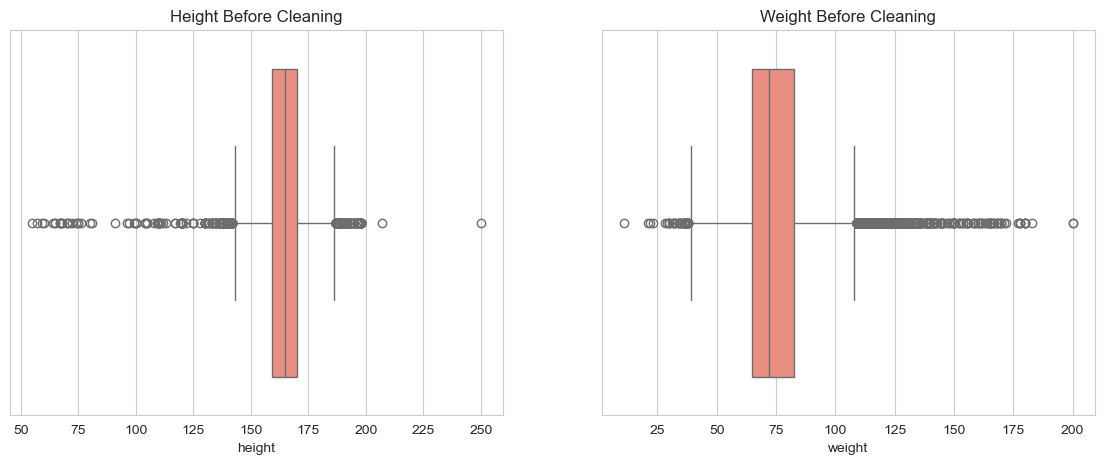

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df["height"], ax=axes[0], color="salmon").set_title(
    "Height Before Cleaning"
)
sns.boxplot(x=df["weight"], ax=axes[1], color="salmon").set_title(
    "Weight Before Cleaning"
)
plt.show()

**Action:**
We will use the **Interquartile Range (IQR)** method to detect and remove these outliers.
Rule: Keep data within $Q1 - 1.5 * IQR$ and $Q3 + 1.5 * IQR$.

In [8]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]


print(f"Rows before outlier removal: {len(df)}")

# Apply to Height and Weight
df = remove_outliers_iqr(df, "height")
df = remove_outliers_iqr(df, "weight")

print(f"Rows after outlier removal: {len(df)}")

Rows before outlier removal: 64853
Rows after outlier removal: 62665


**Validation (After):**

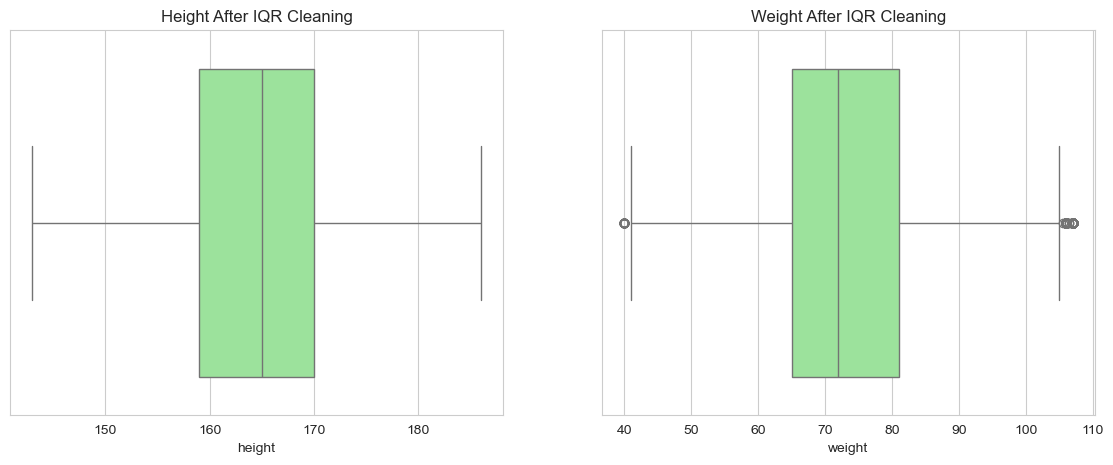

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df["height"], ax=axes[0], color="lightgreen").set_title(
    "Height After IQR Cleaning"
)
sns.boxplot(x=df["weight"], ax=axes[1], color="lightgreen").set_title(
    "Weight After IQR Cleaning"
)
plt.show()

## 5. Feature Engineering: BMI
We will create the Body Mass Index (BMI) feature, which is a strong predictor for heart disease.
$$BMI = \frac{Weight (kg)}{Height (m)^2}$$

In [10]:
# Calculate BMI
# Note: Height is in cm, convert to meters
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# Check the head to see new column
display(df[["weight", "height", "bmi"]].head())

,weight,height,bmi
0,62.0,168,21.967120
1,85.0,156,34.927679
2,64.0,165,23.507805
3,82.0,169,28.710479
4,56.0,156,23.011177


## 6. Encoding Categorical Features
Machine Learning models (like Logistic Regression) perform better when categorical numbers (1, 2, 3) are treated as distinct flags rather than a single number with order.

**Features to Encode:**
* `cholesterol` (1: Normal, 2: Above Normal, 3: Well Above)
* `gluc` (Glucose)

We will use **One-Hot Encoding** (get_dummies).

In [11]:
# One-Hot Encode Cholesterol and Glucose
df = pd.get_dummies(df, columns=["cholesterol", "gluc"], prefix=["chol", "gluc"])

# We set drop_first=False to keep all categories explicit for this project,
# though often in stats we drop one to avoid dummy variable trap.
# For modern ML libs, keeping them is often fine/interpretable.
# Let's convert the booleans (True/False) to Integers (1/0)
bool_cols = [col for col in df.columns if "chol_" in col or "gluc_" in col]
df[bool_cols] = df[bool_cols].astype(int)

display(df.head())

,age_years,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,bmi,chol_1,chol_2,chol_3,gluc_1,gluc_2,gluc_3
0,50,2,168,62.0,110,80,0,0,1,0,21.967120,1,0,0,1,0,0
1,55,1,156,85.0,140,90,0,0,1,1,34.927679,0,0,1,1,0,0
2,52,1,165,64.0,130,70,0,0,0,1,23.507805,0,0,1,1,0,0
3,48,2,169,82.0,150,100,0,0,1,1,28.710479,1,0,0,1,0,0
4,48,1,156,56.0,100,60,0,0,0,0,23.011177,1,0,0,1,0,0


## 7. Train-Test Split
Before we scale the data (normalization), we **must** split it into training and testing sets.
* **Reason:** We calculate the mean/std dev ONLY on the training set to prevent "data leakage" (information from the test set leaking into the training process).

In [12]:
# Features (X) and Target (y)
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Split 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Training Shape: (50132, 16)
Testing Shape: (12533, 16)


## 8. Feature Scaling
We will scale numerical features to have a mean of 0 and a standard deviation of 1 (StandardScaler).

**Features to Scale:** `age_years`, `height`, `weight`, `ap_hi`, `ap_lo`, `bmi`.

In [13]:
# Identify numerical columns to scale
scale_cols = ["age_years", "height", "weight", "ap_hi", "ap_lo", "bmi"]

scaler = StandardScaler()

# FIT on TRAIN, TRANSFORM on TRAIN and TEST
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

# Check if it worked (Mean should be ~0, Std ~1)
print("Scaled Training Data Stats:")
display(X_train[scale_cols].describe().T)

Scaled Training Data Stats:


,count,mean,std,min,25%,50%,75%,max
age_years,50132.0,-1.839712e-16,1.00001,-3.419609,-0.778094,0.102411,0.689414,1.716670
height,50132.0,-1.425848e-16,1.00001,-2.775353,-0.689454,-0.037611,0.744601,2.830499
weight,50132.0,-4.019587e-16,1.00001,-2.655109,-0.660886,-0.102503,0.615417,2.689409
ap_hi,50132.0,-2.605078e-16,1.00001,-3.962764,-0.397859,-0.397859,0.790443,6.731952
ap_lo,50132.0,1.267105e-16,1.00001,-5.351653,-0.124494,-0.124494,0.920938,7.193529
bmi,50132.0,-8.502999e-16,1.00001,-2.938762,-0.713591,-0.171420,0.611964,4.513053


## 9. Save Processed Data
We will save the processed datasets and the scaler for later use.

In [14]:
# Save Dataframes
# Combine X and y back briefly to save as CSV
train_data = X_train.copy()
train_data["cardio"] = y_train

test_data = X_test.copy()
test_data["cardio"] = y_test

train_data.to_csv("../data/processed/train.csv", index=False)
test_data.to_csv("../data/processed/test.csv", index=False)

# Save the Scaler Object
joblib.dump(scaler, "../flask_app/scaler.pkl")

print("✅ Data and Scaler saved successfully!")
print(f"Train path: data/processed/train.csv")
print(f"Test path: data/processed/test.csv")
print(f"Scaler path: flask_app/scaler.pkl")

✅ Data and Scaler saved successfully!
Train path: data/processed/train.csv
Test path: data/processed/test.csv
Scaler path: flask_app/scaler.pkl


## 10. Conclusion
We have successfully prepared the data for Machine Learning.

**Summary of Changes:**
1.  Removed duplicates and impossible blood pressure values.
2.  Removed height/weight outliers using IQR.
3.  Created `bmi` feature.
4.  One-Hot Encoded Cholesterol and Glucose levels.
5.  Split data into Train/Test.
6.  Scaled numerical features.


## ⏭️ Next Step: Model Building (From Scratch)
In **Notebook 3**, we will build a **Logistic Regression Model** entirely from scratch using Python and NumPy (no Scikit-Learn for the model logic). We will implement:
* Sigmoid Activation Function
* Cost Function (Log Loss)
* Gradient Descent Optimization

👉 **Proceed to `notebooks/03_model_from_scratch.ipynb`.**